In [1]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

# =========================
# Load The Dataset
# =========================

df = pd.read_csv("df_preprocessed.csv")
df

,cleaned_text,label_encoded,word_count,text_length,avg_word_length,punct_count,uppercase_ratio
0,nevermind every other weekend google didnt thi...,1,10,63,5.400000,4,0.035714
1,name arrest lie obstruction fbi collusion calm...,1,9,56,5.333333,2,0.083333
2,well damn im go buckingham today,1,6,32,4.500000,0,0.069767
3,these both beauties those big dark eye smile,0,8,44,4.625000,2,0.033333
4,remind days,1,2,11,5.000000,1,0.000000
...,...,...,...,...,...,...,...
20960,bipolar panic disorder when panic disorder sta...,2,29,198,5.862069,6,0.010676
20961,when im stress which most time anger get worse,1,9,46,4.222222,0,0.029851
20962,exactly helpful single parent overwhelm even a...,2,20,120,5.050000,3,0.017241
20963,without school youll get even more stress end,1,8,45,4.750000,1,0.018519


In [2]:
# =========================
# Inputs and Labels
# =========================
X = df['cleaned_text'].astype(str)
y = df['label_encoded']

In [3]:
# =========================
# Convert Labels to Categorical
# =========================

y = to_categorical(y, num_classes=3)

In [4]:
# =========================
# Train-Test Split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
# =========================
# Tokenization
# =========================

max_words = 5000

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


In [6]:
# =========================
# Padding
# =========================

max_length = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

In [7]:
# =========================
# Build LSTM Model
# =========================

model = Sequential()

model.add(Embedding(input_dim=max_words,output_dim=64,input_length=max_length))

model.add(LSTM(64))

model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [8]:
# =========================
# Compile The Model
# =========================

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [10]:
# =========================
# Early Stopping
# =========================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)

In [11]:
# =========================
# Train Model
# =========================

history = model.fit(X_train_pad,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.7034 - loss: 0.6938 - val_accuracy: 0.7839 - val_loss: 0.5610
Epoch 2/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.8273 - loss: 0.4474 - val_accuracy: 0.7803 - val_loss: 0.5589
Epoch 3/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.8618 - loss: 0.3694 - val_accuracy: 0.7633 - val_loss: 0.6154
Epoch 4/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8884 - loss: 0.3121 - val_accuracy: 0.7747 - val_loss: 0.6262
Epoch 5/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9057 - loss: 0.2683 - val_accuracy: 0.7666 - val_loss: 0.7116


In [12]:
# =========================
# Evaluate
# =========================

loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7589 - loss: 0.7174
Test Accuracy: 0.7588838338851929


In [13]:
# =========================
# Predictions
# =========================

y_pred = model.predict(X_test_pad)

y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


In [14]:
# =========================
# Classification Report
# =========================
from sklearn.metrics import classification_report

print(classification_report(y_test_classes,y_pred_classes))

              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1366
           1       0.77      0.72      0.75      1307
           2       0.74      0.80      0.77      1520

    accuracy                           0.76      4193
   macro avg       0.76      0.76      0.76      4193
weighted avg       0.76      0.76      0.76      4193



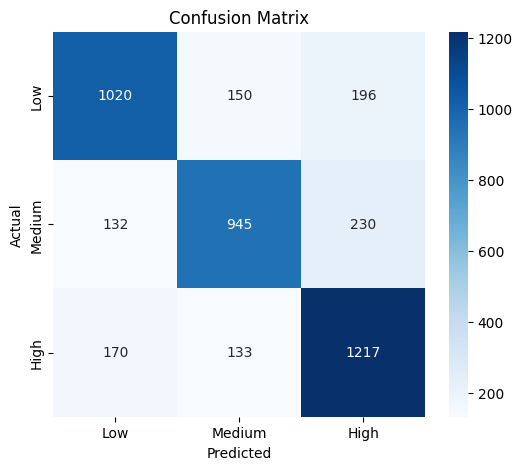

In [19]:
# =========================
# Confusion Matrix
# =========================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define The labels
labels = ['Low', 'Medium', 'High']

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

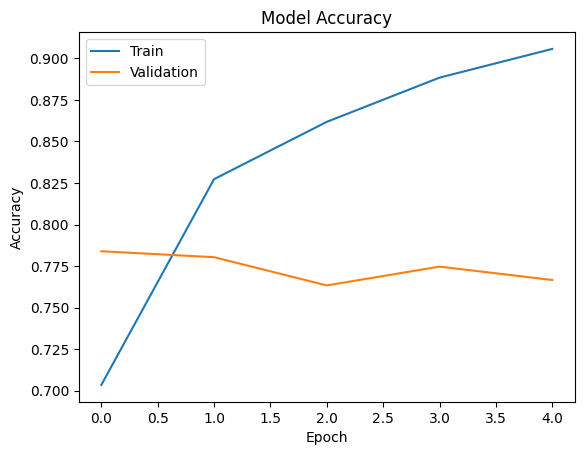

In [20]:
# =========================
# Accuracy Graph
# =========================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

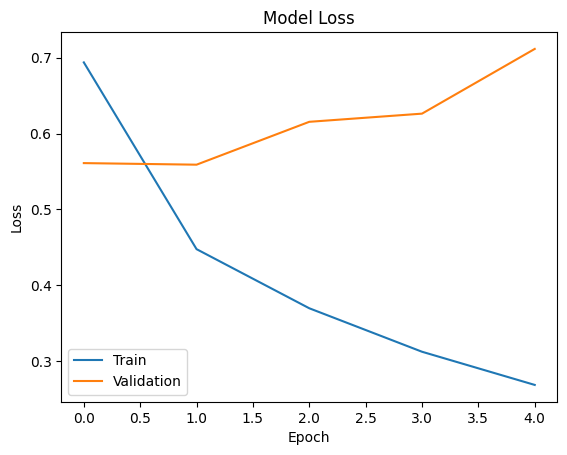

In [21]:
# =========================
# Loss Graph
# =========================

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [22]:
# =========================
# Example Predictions
# =========================

print("\nSample Predictions:\n")

for i in range(5):
    print("Text:", X_test.iloc[i])
    print("Actual:", labels[y_test_classes[i]])
    print("Predicted:", labels[y_pred_classes[i]])
    print("------")


Sample Predictions:

Text: great video presentation burnout way depression dr mark differentiate two well big issue course whether workers need slippery slope into depression some may know mental disorder such as clinical depression rob people life expectancy suppose live get years less workers need ask themselves serious question score highly one one more three domains maslach suggest follow organisation other people around burn suffer other workprecipitated mental disorder eg anxiety disorder depression substance misuse disorder why get point how long all go why fix system after long because burnout doesnt develop overnight how likely fix workplace issue next months hold job more months im clinically depress now succumb develop clinical depression mean allow myself make ill job next obviously cant answer those question each person nor advise next ask oneself question honest better
Actual: Medium
Predicted: High
------
Text: use subconscious rewire release anxiety clients try doesnt 

In [24]:
# =========================
# Create Results DataFrame
# =========================

results_df = pd.DataFrame({
    'text': X_test,
    'actual': y_test_classes,
    'predicted': y_pred_classes
})

# Convert numbers → labels
results_df['actual_label'] = results_df['actual'].map({
    0: 'Low',
    1: 'Medium',
    2: 'High'
})

results_df['predicted_label'] = results_df['predicted'].map({
    0: 'Low',
    1: 'Medium',
    2: 'High'
})

# =========================
# Save to CSV
# =========================

results_df.to_csv("lstm_predictions.csv", index=False)

print("Results saved to lstm_predictions.csv")

Results saved to lstm_predictions.csv
